In [67]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
print("SciPy is working!")

SciPy is working!


In [68]:
#reading the csv file
df=pd.read_csv("Nat_Gas.csv")
print(df.head())

      Dates  Prices
0  10/31/20    10.1
1  11/30/20    10.3
2  12/31/20    11.0
3   1/31/21    10.9
4   2/28/21    10.9


In [69]:
#converting the date column to datetime format
df['Dates'] = pd.to_datetime(df['Dates'])
print(df.dtypes)

Dates     datetime64[us]
Prices           float64
dtype: object


C:\Users\malin\AppData\Local\Temp\ipykernel_12896\128608569.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


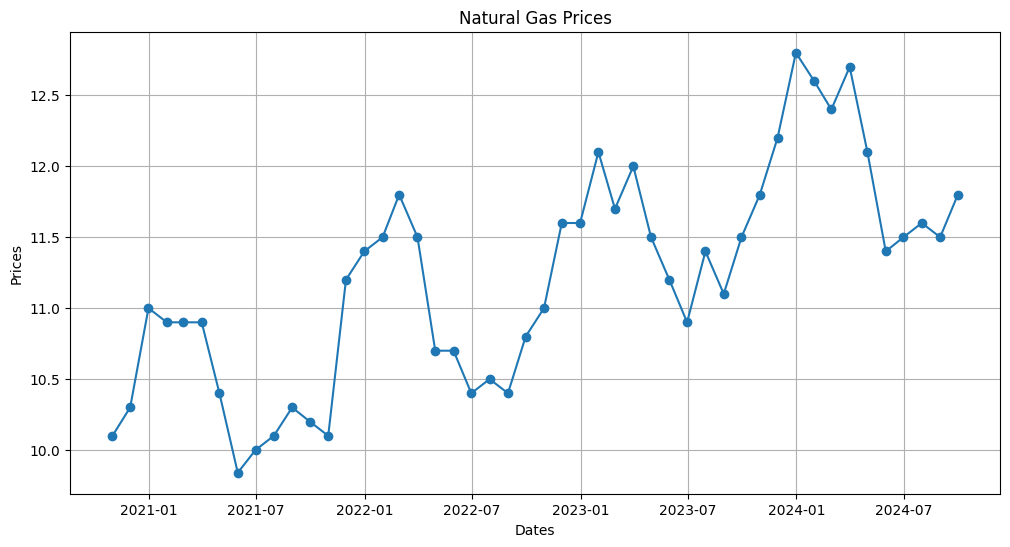

In [70]:
#plotting the data
df['Dates'] = pd.to_datetime(df['Dates'])

plt.figure(figsize=(12, 6))
plt.plot(df['Dates'], df['Prices'], marker='o')

plt.title("Natural Gas Prices")
plt.xlabel("Dates")
plt.ylabel("Prices")

plt.grid(True)
plt.show()

#From the graph we can see natural gas prices exhibit seasonal fluctuations, typically increasing during colder months due to higher heating demand and declining during warmer months.

In [71]:
#creating a new column 'Days' to represent the number of days since the first date in the dataset
df['Days'] = (df['Dates'] - df['Dates'].min()).dt.days
print(df.head())

       Dates  Prices  Days
0 2020-10-31    10.1     0
1 2020-11-30    10.3    30
2 2020-12-31    11.0    61
3 2021-01-31    10.9    92
4 2021-02-28    10.9   120


In [72]:
#taking date as input and returning estimated price
interp_model = interp1d(
    df['Days'],
    df['Prices'],
    kind='linear',
    fill_value='extrapolate'
)

In [73]:
#calculating the average monthly change in natural gas prices
monthly_change = df['Prices'].diff().mean()
print(f"Average monthly change in natural gas prices: {monthly_change:.2f}")

Average monthly change in natural gas prices: 0.04


In [74]:
#generating future dates
future_dates = pd.date_range(
    start = df['Dates'].max(),
    periods = 13,
    freq = 'ME'
)[1:]
print(future_dates)

DatetimeIndex(['2024-10-31', '2024-11-30', '2024-12-31', '2025-01-31',
               '2025-02-28', '2025-03-31', '2025-04-30', '2025-05-31',
               '2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30'],
              dtype='datetime64[us]', freq='ME')


In [75]:
#predicting future prices based on the average monthly change
last_price = df['Prices'].iloc[-1]
future_prices = []
for i in range(12):
    future_prices.append(
        last_price + monthly_change * (i + 1)
    )
print(future_prices)

[np.float64(11.836170212765959), np.float64(11.872340425531915), np.float64(11.908510638297873), np.float64(11.944680851063831), np.float64(11.980851063829789), np.float64(12.017021276595745), np.float64(12.053191489361703), np.float64(12.089361702127661), np.float64(12.125531914893617), np.float64(12.161702127659575), np.float64(12.197872340425533), np.float64(12.23404255319149)]


In [76]:
#creating a DataFrame to display future dates and predicted prices
future_df = pd.DataFrame({ 
    'Dates': future_dates,
    'Prices': future_prices
})
print(future_df)

        Dates     Prices
0  2024-10-31  11.836170
1  2024-11-30  11.872340
2  2024-12-31  11.908511
3  2025-01-31  11.944681
4  2025-02-28  11.980851
5  2025-03-31  12.017021
6  2025-04-30  12.053191
7  2025-05-31  12.089362
8  2025-06-30  12.125532
9  2025-07-31  12.161702
10 2025-08-31  12.197872
11 2025-09-30  12.234043


In [77]:
#displaying the last few rows of the future DataFrame
future_df.tail()

,Dates,Prices
7,2025-05-31,12.089362
8,2025-06-30,12.125532
9,2025-07-31,12.161702
10,2025-08-31,12.197872
11,2025-09-30,12.234043


In [78]:
#combining the original DataFrame with the future DataFrame
combined = pd.concat([df[['Dates', 'Prices']],
                      future_df])
combined['Dates'] = pd.to_datetime(combined['Dates'], format = 'mixed').dt.date
print(combined.tail())

         Dates     Prices
7   2025-05-31  12.089362
8   2025-06-30  12.125532
9   2025-07-31  12.161702
10  2025-08-31  12.197872
11  2025-09-30  12.234043


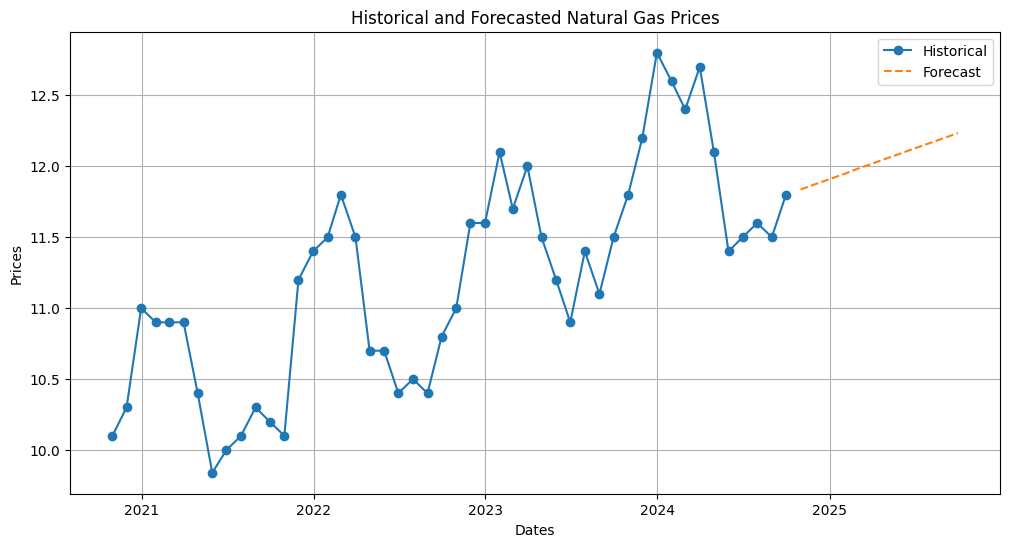

In [79]:
#plotting historical and forecast data
plt.figure(figsize=(12,6))

plt.plot(pd.to_datetime(df['Dates']), 
         df['Prices'], 
         label='Historical',
         marker ='o')
plt.plot(pd.to_datetime(future_df['Dates']), 
         future_df['Prices'], 
         '--', 
         label='Forecast')
plt.title('Historical and Forecasted Natural Gas Prices')
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.legend()
plt.grid(True)
plt.show()


In [80]:
#taking date as input and returning estimated price
def estimated_price(date_string):
    date = pd.to_datetime(date_string)

    days = (
        date - pd.to_datetime(df['Dates'].min())
    ).days

    return float(interp_model(days))

In [81]:
#an example to see if it works
price = estimated_price(
    '2023-06-15'
)

print(price)

11.05


In [82]:
#To see if it can handle future dates too
price = estimated_price(
    '2030-02-19'
)
print(price)

31.480000000000018


In [83]:
#My Analysis: The data was visualized to identify trends and seasonality. 
# Natural gas prices generally display seasonal behavior, with higher prices during colder months due to increased heating demand. 
# Historical prices were modeled using linear interpolation, allowing estimation of prices on dates between monthly observations. 
# Future prices were extrapolated for one year beyond the available data using the historical trend. 
# A Python function was developed that accepts a date and returns an estimated natural gas price.